<a href="https://colab.research.google.com/github/CasSteur/numeriek-hand-in-1/blob/main/SOM_handin2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
2# If you are on google-colab you will need to first install sisl
!pip install sisl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 56.1 MB/s eta 0:00:00


In [3]:
  #We begin by importing numpy and pyplot
import sisl
import numpy as np
from helper_functions import *
import matplotlib.pyplot as plt
##This one is so that you can rotate the 3D images we will create
#%matplotlib ipympl  ## If you have ipympl installed you can uncomment this line

/content/helper_functions.py:98: SyntaxWarning: invalid escape sequence '\m'
  Rvec="\mathbf{{R}}_{dim}".format(dim=dim+1)
/content/helper_functions.py:99: SyntaxWarning: invalid escape sequence '\m'
  kvec="\mathbf{{k}}_{dim}".format(dim=dim+1)
/content/helper_functions.py:102: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "-\imath {Rkvec}".format(Rkvec=Rkvec)
/content/helper_functions.py:105: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "+\imath {Rkvec}".format(Rkvec=Rkvec,sc=-Rdiff[dim])
/content/helper_functions.py:108: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "-\imath {sc} {Rkvec}".format(Rkvec=Rkvec,sc=-Rdiff[dim])
/content/helper_functions.py:112: SyntaxWarning: invalid escape sequence '\i'
  MomPart += "+\imath {sc} {Rkvec}".format(Rkvec=Rkvec,sc=Rdiff[dim])


**Question 1: The infinite SSH Chain**

Perform a tight-binding calculation on a in infinite chain with t1 = −2 eV and t2 = −1
eV. Plot the dispersion relation as a function of the momentum k. Does the image change
if t2 = −2 eV and t1 = −1 eV? For convenience, you may set the on-site energy to zero
in the questions that follow and it is sufficient to consider only the one state per C atom
(the pz orbital). Feel free to make use of previous python notebooks for inspiration.

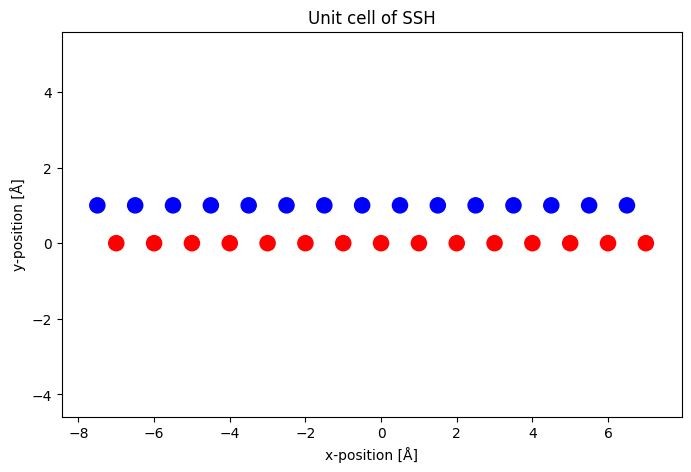

In [4]:
a=1 #distance between C atoms in Å
N = 15 #number of unit cells
k = 1 # dit moet anders want je wilt straks een functie van k maken...
h = 1

vector1 = np.array([a,0,0])             # Lattice vector (one vector for 1 dimention)
pos = np.array([[0,0,0],[-h/2,h,0]])  # Position of the two atom
lattice=sisl.Lattice([vector1,[0,3*h,0],[0,0,h]], nsc =[N,1,1]) ##We need to specify a lattice and give to SISL

geomSSH = sisl.Geometry(xyz = pos, lattice=lattice)

PlotGeometry(geomSSH,color=["red","blue"],hold_show=True);
plt.title("Unit cell of SSH");





Hamiltonian is hermitian!


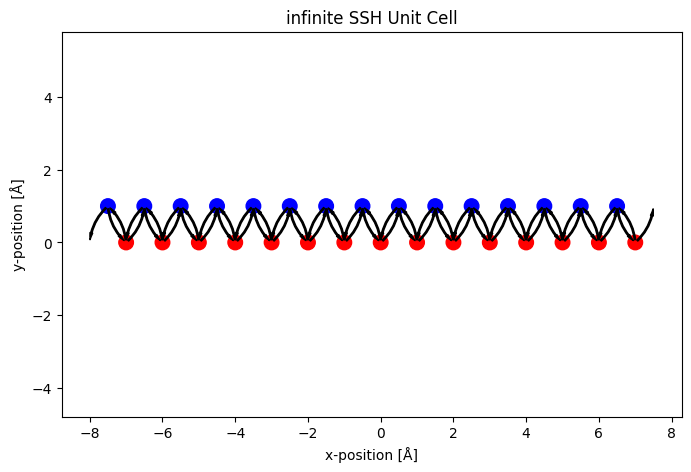

In [5]:
from IPython.core.application import BaseIPythonApplication

# create matrix
H_SSHinf = sisl.Hamiltonian(geomSSH) #is maar 2 bij 2 want twee atomen

# Assign hopping
t2 = -1.0 #eV
t1 = -2.0 #eV
onsite_E = 0  #eV Onsite energy

# Assign the hopping terms to another unit cell
H_SSHinf[0,1,(1, 0, 0)]= t2
H_SSHinf[1,0,(-1,0,0)]= t2

# Assign the hopping terms within the cell
H_SSHinf[0,1,(0, 0, 0)]= t1
H_SSHinf[1,0,(0,0,0)]= t1

PlotHamTerms(H_SSHinf,color=["red","blue"],hold_show=True);
plt.title("infinite SSH Unit Cell");
CheckHermiticity(H_SSHinf) ###This checks that the hamiltonian is hermitian





In [6]:
## print to test
#Numeric representation in Tex
print("Numerical matrix in Tex")
PrintMomentumRep(H_SSHinf,num_pf=True);

Numerical matrix in Tex


\begin{pmatrix}0 & -1.0e^{-\imath \mathbf{R}_1\mathbf{k}_1}+-2.0 \\ -1.0e^{+\imath \mathbf{R}_1\mathbf{k}_1}+-2.0 & 0\end{pmatrix}

Plotting the energy eigenvalues for different values of k from our Hamiltonian matrix shown above this text.

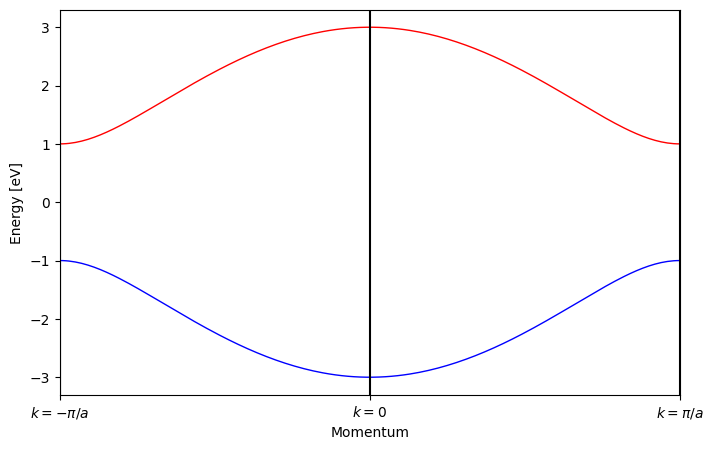

In [7]:
# Compute bands along a path in k.
KPath=[[ -0.5, 0.0, 0.0], # start of the path in reciprocal units (-pi/a,0,0)
        [ 0.0, 0.0, 0.0], # k=0
        [+0.5, 0.0, 0.0]]  # End of the path in reciprocal units. This corresponds to (pi/a,0,0)
PathNames=[r'$k=-\pi/a$',r'$k=0$', r'$k=\pi/a$']
bands2 = sisl.BandStructure(H_SSHinf,KPath,200,PathNames)
plot_bands(bands2,bandcolor=["blue","red"]);

**Question 2: The finite SSH Chain**

Perform a tight-binding calculation on a finite chain of 50 atoms with t1 = −2 eV and
t2 = −1 eV. Plot an energy diagram and comment on the localization of the highestoccupied and lowest-unoccupied molecular orbitals.


Numerical matrix


matrix([[ 0., -2.,  0., ...,  0.,  0.,  0.],
        [-2.,  0., -1., ...,  0.,  0.,  0.],
        [ 0., -1.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0., -1.,  0.],
        [ 0.,  0.,  0., ..., -1.,  0., -2.],
        [ 0.,  0.,  0., ...,  0., -2.,  0.]])

Hamiltonian is hermitian!


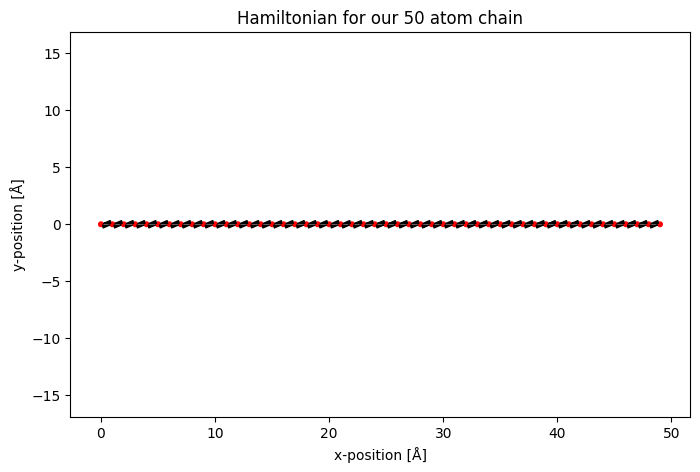

In [47]:
# Assign hopping
t2 = -1.0 #eV
t1 = -2.0 #eV
N = 50 #number of atoms
a = 1 #distance between C atoms in Å

#creating the geomerty for oor 50 atom finite chain
pos = np.array([[i*a,0,0] for i in range(N)])
atoms = [sisl.Atom("C")] * N
geomSSH_fin = sisl.Geometry(pos, atoms = atoms)

# create matrix
H_SSHfin = sisl.Hamiltonian(geomSSH_fin)

#Filling in the matrix
for i in range(N):
  if i % 2 == 0:
    H_SSHfin[i,(i+1) % 50] = t1
    H_SSHfin[i,(i-1) % 50] = t2
  else:
    H_SSHfin[i,(i+1) % 50] = t2
    H_SSHfin[i,(i-1) % 50] = t1

H_SSHfin[0,49] = 0
H_SSHfin[49,0] = 0

#Showing what our matrix looks like
print("Numerical matrix")
display(H_SSHfin.Hk().todense())

CheckHermiticity(H_SSHfin) #This checks that the Hamiltonian is hermitian
PlotHamTerms(H_SSHfin,hold_show=True);
plt.title("Hamiltonian for our 50 atom chain");

Now that we have our matrix, we now need to find it's eigenvectors and eigenvalues. We will also plot these energies.

Text(0.5, 0, 'Eigenstate number')

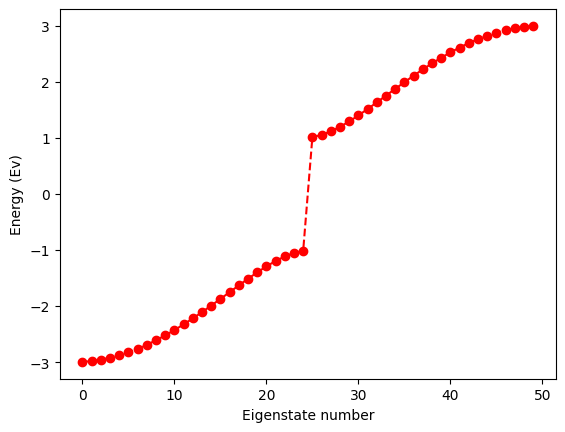

In [48]:
EVal,EVec=np.linalg.eig(H_SSHfin.Hk().todense())
sort_order=np.argsort(EVal)
EVal=EVal[sort_order] ###Sort eigenvalues
EVec=EVec[:,sort_order] ###Sort eigenvectors

plt.plot(EVal,"or--")
plt.ylabel(r"Energy (Ev)")
plt.xlabel("Eigenstate number")





For f we will need to make a plot of the energy levels as a function of the hopping terms ratio t_1/t_2. We will do this by keeping t_2 at -1 eV and varying t_1 from 0 to -2 eV.

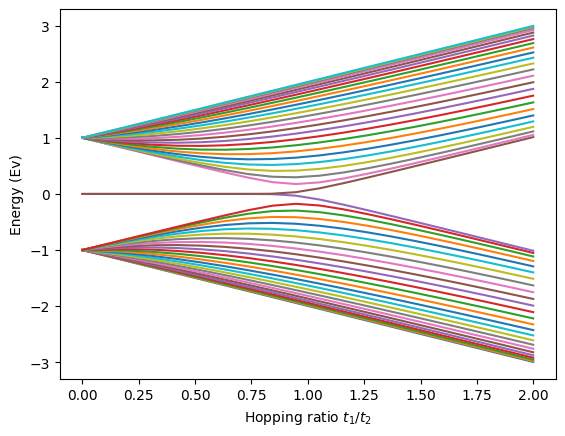

In [66]:
# Assign hopping
t2 = -1.0 #eV
N = 50 #number of atoms
a = 1 #distance between C atoms in Å

# create matrix
H_SSHfin = sisl.Hamiltonian(geomSSH_fin)

#Setting up our values for t_1 and empty lists for our result so we can
#plot them later on
t1_values = np.linspace(0,-2,20)
All_energies = []
hopping_ratios = []

#looping over all different values to the whole calculation for each of them
#the results from this will be put in the empty lists we just made
for t1 in t1_values:
  hopping_ratios.append(t1/t2)
  for i in range(N):
    if i % 2 == 0:
      H_SSHfin[i,(i+1) % 50] = t1
      H_SSHfin[i,(i-1) % 50] = t2
    else:
      H_SSHfin[i,(i+1) % 50] = t2
      H_SSHfin[i,(i-1) % 50] = t1
  H_SSHfin[0,49] = 0
  H_SSHfin[49,0] = 0
  EVal,EVec=np.linalg.eig(H_SSHfin.Hk().todense())
  sort_order=np.argsort(EVal)
  EVal=EVal[sort_order]   #Sort eigenvalues
  EVec=EVec[:,sort_order]   #Sort eigenvectors
  All_energies.append(EVal)

#plotting all energylevels for the different values of t1
plt.figure() #making the figure for our plot
for i in range(N): #putting the energyvalues together per value of t1
  energie_band = [Evalues[i] for Evalues in All_energies]
  plt.plot(hopping_ratios, energie_band)
plt.xlabel('Hopping ratio $t_1/t_2$') #adding axis labels
plt.ylabel('Energy (Ev)')
plt.show()

For question 3 b we plot $d_x$ versus $d_y$ for $k\in[-\frac{\pi}{a},\frac{\pi}{a}]$, where $(d_x,d_y)=(t_1+t_2\cos(ka),t_2\cos(ka))$

In [ ]:
num=100
#define our vector d(k)
def d(k, T1, T2):
  dx=T1+T2*np.cos(k*a)
  dy=T2*np.sin(k*a)
  return (dx,dy)

T1_values = [-1,-1,-1,-0.6,0] #eV
T2_values = [0,-0.6,-1,-1,-1] #eV
k=np.linspace(-np.pi/a, np.pi/a, num=num)

labels= ['I', 'II', 'III', 'IV', 'V']

for idx, (i,j) in enumerate(zip(T1_values, T2_values)):
  dxi,dyi= d(k, i, j)
  plt.plot(dxi, dyi, label=f'{labels[idx]}')
plt.legend()
plt.title(r'$d_x$ vs $d_y$')
plt.xlabel(r'$d_x$')
plt.ylabel(r'$d_y$')
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.4)
plt.show()


